# Custom mini AudioTransformer for audio classification

This notebook shows how to implement a mini transformer model from scratch in PyTorch, without using a ready-made AST from Hugging Face.

Plan:
1. Data preparation based on project utilities (`core/data/io.py`).
2. Convert audio to log-mel spectrograms.
3. Implementation of the mini AudioTransformer (patch embedding + transformer encoder + head).
4. Training and evaluation on the test set.

## How does the mini AudioTransformer work?

The model takes a log-mel spectrogram of shape `[1, n_mels, time]`.
Then:
- `Conv2d` creates patch embeddings (small time-frequency patches),
- patch tokens go to self-attention blocks,
- after pooling, we get a single audio vector,
- and the linear layer returns class logits.

This is a lightweight educational architecture, good for understanding the mechanics of a transformer in audio.

In [ ]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import kagglehub

from core.data.io import (
    scan_labeled_audio,
    split_files_train_val_test,
    load_audio,
    audio_to_logmel,
    N_MELS,
    TARGET_SECONDS,
    SAMPLE_RATE,
    HOP_LENGTH,
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

c:\Users\dusza\Documents\Studia\7semestr\DeepLearning\Audio-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Torch: 2.6.0+cu124


In [2]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3050 Laptop GPU


In [ ]:
# Experiment configuration
DATASET_ID = "andradaolteanu/gtzan-dataset-music-genre-classification"

USED_FRACTION = 0.8
VAL_FRACTION_OF_USED = 0.2
MAX_FILES = None  # e.g. 400 for quick tests
RANDOM_STATE = 42

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-3
MIN_LR = 1e-5
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 2

# Early stopping
EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 1e-4

# Dataset validation
VALIDATION_SAMPLES_PER_SPLIT = 40
SILENCE_RMS_THRESHOLD = 1e-5

# Model saving
ARTIFACTS_DIR = Path("artifacts") / "mini_audio_transformer"

# Audio augmentation (train-only)
AUGMENT_TRAIN = True
GAIN_DB_MAX = 6.0
NOISE_STD_MAX = 0.008
TIME_SHIFT_MAX_FRAC = 0.08
SPEC_MASK_PROB = 0.5
SPEC_TIME_MASK_MAX = 24
SPEC_FREQ_MASK_MAX = 12

# Mini transformer parameters
PATCH_MELS = 16
PATCH_TIME = 16
EMBED_DIM = 128
NUM_HEADS = 8
DEPTH = 6
MLP_RATIO = 4.0
DROPOUT = 0.15

dataset_root = Path(kagglehub.dataset_download(DATASET_ID))
print("Dataset root:", dataset_root)

Dataset root: C:\Users\dusza\.cache\kagglehub\datasets\andradaolteanu\gtzan-dataset-music-genre-classification\versions\1


In [ ]:
# Data scanning and split
files, y, class_names = scan_labeled_audio(dataset_root, max_files=MAX_FILES)
train_files, val_files, test_files, y_train, y_val, y_test = split_files_train_val_test(
    files,
    y,
    used_fraction=USED_FRACTION,
    val_fraction_of_used=VAL_FRACTION_OF_USED,
    random_state=RANDOM_STATE,
)

print(f"Number of classes: {len(class_names)}")
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

split_df = pd.DataFrame(
    {
        "train": np.bincount(y_train, minlength=len(class_names)),
        "val": np.bincount(y_val, minlength=len(class_names)),
        "test": np.bincount(y_test, minlength=len(class_names)),
    },
    index=class_names,
)
split_df.head(10)

Number of classes: 10
Train: 640 | Val: 160 | Test: 200


,train,val,test
blues,64,16,20
classical,64,16,20
country,64,16,20
disco,64,16,20
hiphop,64,16,20
jazz,64,16,20
metal,64,16,20
pop,64,16,20
reggae,64,16,20
rock,64,16,20


## Dataset validation (sanity-check)

Before training, we check quick data quality conditions:
- whether splits are not empty,
- whether each class is present in the training set,
- whether a random sample of files does not produce near-silence (fallback to zeros).

In [ ]:
def validate_split(files_split, split_name, class_names, y_split, sample_size=40, silence_thr=1e-5):
    if len(files_split) == 0:
        raise ValueError(f"Split {split_name} is empty")

    counts = np.bincount(y_split, minlength=len(class_names))
    missing = [class_names[i] for i, c in enumerate(counts) if c == 0]
    if split_name == "train" and missing:
        raise ValueError(f"Missing classes in train: {missing}")

    n = min(sample_size, len(files_split))
    idx = np.random.choice(len(files_split), size=n, replace=False)
    zero_like = 0
    too_short = 0

    for i in idx:
        wav = load_audio(files_split[i], sr=SAMPLE_RATE, seconds=TARGET_SECONDS)
        if len(wav) != SAMPLE_RATE * TARGET_SECONDS:
            too_short += 1
        rms = float(np.sqrt(np.mean(np.square(wav))))
        if rms < silence_thr:
            zero_like += 1

    return {
        "split": split_name,
        "n_files": len(files_split),
        "sample_checked": n,
        "zero_like": zero_like,
        "zero_like_ratio": zero_like / max(1, n),
        "wrong_length": too_short,
    }

validation_rows = [
    validate_split(train_files, "train", class_names, y_train, VALIDATION_SAMPLES_PER_SPLIT, SILENCE_RMS_THRESHOLD),
    validate_split(val_files, "val", class_names, y_val, VALIDATION_SAMPLES_PER_SPLIT, SILENCE_RMS_THRESHOLD),
    validate_split(test_files, "test", class_names, y_test, VALIDATION_SAMPLES_PER_SPLIT, SILENCE_RMS_THRESHOLD),
]

validation_df = pd.DataFrame(validation_rows)
validation_df

,split,n_files,sample_checked,zero_like,zero_like_ratio,wrong_length
0,train,640,40,1,0.025,0
1,val,160,40,0,0.000,0
2,test,200,40,0,0.000,0


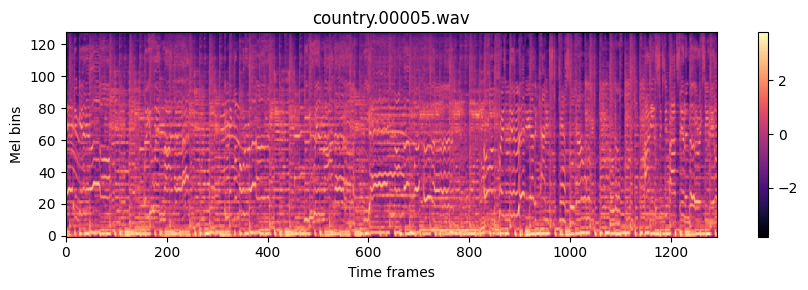

Log-mel shape: (128, 1292)


In [6]:
# Quick log-mel preview for a random sample
example_path = random.choice(train_files)
audio = load_audio(example_path, sr=SAMPLE_RATE, seconds=TARGET_SECONDS)
logmel = audio_to_logmel(audio, sr=SAMPLE_RATE)

plt.figure(figsize=(9, 3))
plt.imshow(logmel, aspect="auto", origin="lower", cmap="magma")
plt.title(Path(example_path).name)
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar()
plt.tight_layout()
plt.show()

print("Log-mel shape:", logmel.shape)

## Dataset and DataLoader + augmentation

Each dataset item returns:
- x: tensor [1, n_mels, time] with a log-mel spectrogram,
- y: class index.

Augmentation is enabled only for train and includes:
- random signal gain,
- light Gaussian noise,
- time shift,
- SpecAugment: masking frequency bands and time segments.

For val and test, augmentation is disabled so metrics remain comparable.

In [7]:
class LogMelDataset(Dataset):
    def __init__(self, files, labels, train=False):
        self.files = list(files)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.train = train

    def __len__(self):
        return len(self.files)

    def _augment_wave(self, wav: np.ndarray) -> np.ndarray:
        # Random gain in dB
        gain_db = np.random.uniform(-GAIN_DB_MAX, GAIN_DB_MAX)
        gain = 10.0 ** (gain_db / 20.0)
        wav = wav * gain

        # Additive Gaussian noise
        noise_std = np.random.uniform(0.0, NOISE_STD_MAX)
        if noise_std > 0:
            wav = wav + np.random.normal(0.0, noise_std, size=wav.shape).astype(np.float32)

        # Random circular time shift
        max_shift = int(TIME_SHIFT_MAX_FRAC * len(wav))
        if max_shift > 0:
            shift = np.random.randint(-max_shift, max_shift + 1)
            wav = np.roll(wav, shift)

        return np.clip(wav, -1.0, 1.0).astype(np.float32)

    def _augment_logmel(self, mel: np.ndarray) -> np.ndarray:
        if np.random.rand() > SPEC_MASK_PROB:
            return mel

        mel_aug = mel.copy()
        n_mels, n_frames = mel_aug.shape

        # Frequency mask
        f = np.random.randint(0, SPEC_FREQ_MASK_MAX + 1)
        if f > 0 and f < n_mels:
            f0 = np.random.randint(0, n_mels - f + 1)
            mel_aug[f0:f0 + f, :] = 0.0

        # Time mask
        t = np.random.randint(0, SPEC_TIME_MASK_MAX + 1)
        if t > 0 and t < n_frames:
            t0 = np.random.randint(0, n_frames - t + 1)
            mel_aug[:, t0:t0 + t] = 0.0

        return mel_aug.astype(np.float32)

    def __getitem__(self, idx):
        path = self.files[idx]
        y = int(self.labels[idx])

        audio = load_audio(path, sr=SAMPLE_RATE, seconds=TARGET_SECONDS)
        if self.train and AUGMENT_TRAIN:
            audio = self._augment_wave(audio)

        mel = audio_to_logmel(audio, sr=SAMPLE_RATE).astype(np.float32)
        if self.train and AUGMENT_TRAIN:
            mel = self._augment_logmel(mel)

        x = torch.from_numpy(mel).unsqueeze(0)  # [1, n_mels, time]
        return x, torch.tensor(y, dtype=torch.long)

train_ds = LogMelDataset(train_files, y_train, train=True)
val_ds = LogMelDataset(val_files, y_val, train=False)
test_ds = LogMelDataset(test_files, y_test, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("Batch x:", tuple(xb.shape))
print("Batch y:", tuple(yb.shape))

Batch x: (16, 1, 128, 1292)
Batch y: (16,)


In [8]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        attn_in = self.norm1(x)
        attn_out, _ = self.attn(attn_in, attn_in, attn_in, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x


class MiniAudioTransformer(nn.Module):
    def __init__(
        self,
        n_classes: int,
        n_mels: int = N_MELS,
        patch_mels: int = 16,
        patch_time: int = 16,
        embed_dim: int = 128,
        depth: int = 4,
        num_heads: int = 4,
        mlp_ratio: float = 4.0,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.patch_embed = nn.Conv2d(
            in_channels=1,
            out_channels=embed_dim,
            kernel_size=(patch_mels, patch_time),
            stride=(patch_mels, patch_time),
        )

        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                )
                for _ in range(depth)
            ]
)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, 1, n_mels, time]
        x = self.patch_embed(x)           # [B, E, H', W']
        x = x.flatten(2).transpose(1, 2)  # [B, N, E]

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        x = x.mean(dim=1)                 # global average over patch tokens
        logits = self.head(x)
        return logits

model = MiniAudioTransformer(
    n_classes=len(class_names),
    n_mels=N_MELS,
    patch_mels=PATCH_MELS,
    patch_time=PATCH_TIME,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model.__class__.__name__)
print(f"Trainable params: {n_params:,}")

MiniAudioTransformer
Trainable params: 1,224,074


## LR scheduler and early stopping

LR Scheduler:
- first a short warmup (stable start),
- then cosine decay to MIN_LR.

Early stopping:
- we monitor val_f1,
- if there is no improvement greater than the minimum threshold for several epochs, training stops early.

This usually improves stability and reduces overfitting.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

steps_per_epoch = max(1, len(train_loader))
warmup_steps = max(1, WARMUP_EPOCHS * steps_per_epoch)
cosine_steps = max(1, (EPOCHS * steps_per_epoch) - warmup_steps)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.2,
    end_factor=1.0,
    total_iters=warmup_steps,
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cosine_steps,
    eta_min=MIN_LR,
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[warmup_steps],
)

def run_epoch(model, loader, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    losses = []
    y_true = []
    y_pred = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

        losses.append(float(loss.item()))
        preds = torch.argmax(logits, dim=1)
        y_true.append(yb.detach().cpu().numpy())
        y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    metrics = {
        "loss": float(np.mean(losses)),
        "acc": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    }
    return metrics

history = []
best_val_f1 = -1.0
best_state = None
best_epoch = 0
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, optimizer=optimizer, scheduler=scheduler)
    with torch.no_grad():
        val_metrics = run_epoch(model, val_loader, optimizer=None, scheduler=None)

    current_lr = float(optimizer.param_groups[0]["lr"])
    row = {
        "epoch": epoch,
        "lr": current_lr,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "train_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1": val_metrics["macro_f1"],
    }
    history.append(row)

    improved = val_metrics["macro_f1"] > (best_val_f1 + EARLY_STOPPING_MIN_DELTA)
    if improved:
        best_val_f1 = val_metrics["macro_f1"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:02d} | lr={current_lr:.6f} | "
        f"train loss={row['train_loss']:.4f} acc={row['train_acc']:.4f} f1={row['train_f1']:.4f} | "
        f"val loss={row['val_loss']:.4f} acc={row['val_acc']:.4f} f1={row['val_f1']:.4f}"
    )

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping at epoch {epoch}. "
            f"Best val_f1={best_val_f1:.4f} from epoch {best_epoch}."
        )
        break

history_df = pd.DataFrame(history)

# Save the best model and metadata
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
weights_path = ARTIFACTS_DIR / "mini_audio_transformer_best.pt"
history_path = ARTIFACTS_DIR / "train_history.csv"
meta_path = ARTIFACTS_DIR / "meta.pt"

if best_state is None:
    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

torch.save(best_state, weights_path)
history_df.to_csv(history_path, index=False)
torch.save(
    {
        "class_names": class_names,
        "params": {
            "PATCH_MELS": PATCH_MELS,
            "PATCH_TIME": PATCH_TIME,
            "EMBED_DIM": EMBED_DIM,
            "NUM_HEADS": NUM_HEADS,
            "DEPTH": DEPTH,
            "MLP_RATIO": MLP_RATIO,
            "DROPOUT": DROPOUT,
            "N_MELS": N_MELS,
            "AUGMENT_TRAIN": AUGMENT_TRAIN,
            "GAIN_DB_MAX": GAIN_DB_MAX,
            "NOISE_STD_MAX": NOISE_STD_MAX,
            "TIME_SHIFT_MAX_FRAC": TIME_SHIFT_MAX_FRAC,
            "SPEC_MASK_PROB": SPEC_MASK_PROB,
            "SPEC_TIME_MASK_MAX": SPEC_TIME_MASK_MAX,
            "SPEC_FREQ_MASK_MAX": SPEC_FREQ_MASK_MAX,
            "MIN_LR": MIN_LR,
            "WARMUP_EPOCHS": WARMUP_EPOCHS,
            "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
            "EARLY_STOPPING_MIN_DELTA": EARLY_STOPPING_MIN_DELTA,
        },
        "best_val_f1": float(best_val_f1),
        "best_epoch": int(best_epoch),
    },
    meta_path,
)

print(f"Saved weights: {weights_path}")
print(f"Saved history: {history_path}")
print(f"Saved meta: {meta_path}")

history_df

Epoch 01 | lr=0.000600 | train loss=2.1429 acc=0.1984 f1=0.1874 | val loss=1.9702 acc=0.2437 f1=0.1559


c:\Users\dusza\Documents\Studia\7semestr\DeepLearning\Audio-Classification\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 02 | lr=0.001000 | train loss=1.9131 acc=0.2922 f1=0.2620 | val loss=1.7260 acc=0.3875 f1=0.3490
Epoch 03 | lr=0.000992 | train loss=1.7188 acc=0.3375 f1=0.3257 | val loss=1.6044 acc=0.4250 f1=0.3764
Epoch 04 | lr=0.000970 | train loss=1.6085 acc=0.4016 f1=0.3854 | val loss=1.6775 acc=0.3500 f1=0.3162
Epoch 05 | lr=0.000934 | train loss=1.5379 acc=0.4281 f1=0.4189 | val loss=1.4991 acc=0.4688 f1=0.4053
Epoch 06 | lr=0.000884 | train loss=1.4483 acc=0.4719 f1=0.4618 | val loss=1.4707 acc=0.4750 f1=0.4239
Epoch 07 | lr=0.000823 | train loss=1.4410 acc=0.4688 f1=0.4596 | val loss=1.5381 acc=0.4313 f1=0.3843
Epoch 08 | lr=0.000752 | train loss=1.3265 acc=0.5344 f1=0.5209 | val loss=1.3576 acc=0.4750 f1=0.4422
Epoch 09 | lr=0.000674 | train loss=1.2542 acc=0.5641 f1=0.5523 | val loss=1.5009 acc=0.4625 f1=0.4123
Epoch 10 | lr=0.000591 | train loss=1.1928 acc=0.5875 f1=0.5831 | val loss=1.2764 acc=0.4938 f1=0.4773
Epoch 11 | lr=0.000505 | train loss=1.0957 acc=0.6281 f1=0.6231 | val los

,epoch,lr,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.000600,2.142940,0.198437,0.187385,1.970232,0.24375,0.155891
1,2,0.001000,1.913058,0.292187,0.262048,1.725990,0.38750,0.349007
2,3,0.000992,1.718778,0.337500,0.325656,1.604352,0.42500,0.376422
3,4,0.000970,1.608463,0.401562,0.385351,1.677505,0.35000,0.316239
4,5,0.000934,1.537917,0.428125,0.418874,1.499125,0.46875,0.405314
5,6,0.000884,1.448349,0.471875,0.461789,1.470678,0.47500,0.423887
6,7,0.000823,1.440998,0.468750,0.459602,1.538073,0.43125,0.384256
7,8,0.000752,1.326486,0.534375,0.520876,1.357592,0.47500,0.442227
8,9,0.000674,1.254200,0.564063,0.552293,1.500950,0.46250,0.412329
9,10,0.000591,1.192817,0.587500,0.583124,1.276412,0.49375,0.477288


Test accuracy: 0.5950
Test macro F1: 0.5934


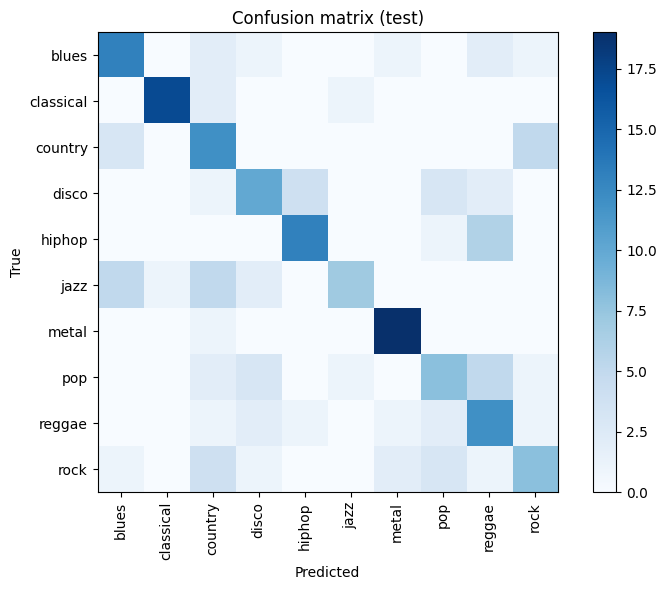

,file,true_label,predicted_label,correct,confidence
0,C:\Users\dusza\.cache\kagglehub\datasets\andra...,classical,classical,True,0.968075
1,C:\Users\dusza\.cache\kagglehub\datasets\andra...,blues,blues,True,0.807400
2,C:\Users\dusza\.cache\kagglehub\datasets\andra...,metal,metal,True,0.406019
3,C:\Users\dusza\.cache\kagglehub\datasets\andra...,jazz,jazz,True,0.489526
4,C:\Users\dusza\.cache\kagglehub\datasets\andra...,blues,blues,True,0.817911
5,C:\Users\dusza\.cache\kagglehub\datasets\andra...,country,country,True,0.504260
6,C:\Users\dusza\.cache\kagglehub\datasets\andra...,rock,country,False,0.731570
7,C:\Users\dusza\.cache\kagglehub\datasets\andra...,country,rock,False,0.360947
8,C:\Users\dusza\.cache\kagglehub\datasets\andra...,hiphop,hiphop,True,0.581897
9,C:\Users\dusza\.cache\kagglehub\datasets\andra...,jazz,classical,False,0.871712


In [10]:
# Load the best validation model and compute test metrics
weights_path = ARTIFACTS_DIR / "mini_audio_transformer_best.pt"

if weights_path.exists():
    model.load_state_dict(torch.load(weights_path, map_location=device))
elif best_state is not None:
    model.load_state_dict(best_state)

model.eval()
all_logits = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu())
        all_targets.append(yb.cpu())

test_logits = torch.cat(all_logits, dim=0).numpy()
test_targets = torch.cat(all_targets, dim=0).numpy()
test_preds = np.argmax(test_logits, axis=1)

test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds, average="macro")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test macro F1: {test_f1:.4f}")

proba = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
confidence = proba.max(axis=1)

results = pd.DataFrame({
    "file": [str(p) for p in test_files],
    "true_label": [class_names[int(i)] for i in test_targets],
    "predicted_label": [class_names[int(i)] for i in test_preds],
    "correct": (test_targets == test_preds),
    "confidence": confidence,
})

cm = confusion_matrix(test_targets, test_preds)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion matrix (test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

results.head(20)

## Quick tuning: compare several configurations

The section below runs a few experiments and collects the results in a single table.
Each experiment trains the model from scratch and reports:
- best val_f1,
- test accuracy and test macro F1,
- the number of parameters and architecture/training settings.

Tip: on a laptop, start with 3 experiments and 10-12 epochs.

In [ ]:
# Experiment settings
TUNE_EPOCHS = 12
TUNE_PATIENCE = 3
TUNE_MIN_LR = 1e-5
TUNE_WARMUP_EPOCHS = 2
TUNE_LR = 3e-4
TUNE_WEIGHT_DECAY = 3e-4

Running experiment: base_4x4_p16


c:\Users\dusza\Documents\Studia\7semestr\DeepLearning\Audio-Classification\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  val_f1=0.5015 | test_f1=0.4845
Running experiment: strong_6x8_p16


c:\Users\dusza\Documents\Studia\7semestr\DeepLearning\Audio-Classification\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  val_f1=0.5077 | test_f1=0.5671
Running experiment: finer_time_6x8_p8


c:\Users\dusza\Documents\Studia\7semestr\DeepLearning\Audio-Classification\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


  val_f1=0.5223 | test_f1=0.5559


,name,depth,heads,embed,patch_time,dropout,params,val_acc,val_f1,test_acc,test_f1
1,strong_6x8_p16,6,8,128,16,0.15,1224074,0.53125,0.507692,0.590,0.567130
2,finer_time_6x8_p8,6,8,128,8,0.15,1207690,0.55000,0.522349,0.580,0.555903
0,base_4x4_p16,4,4,128,16,0.10,827530,0.51875,0.501508,0.515,0.484508


After running the previous cell, you will get the `tune_df` table.
The most important columns for decision making:
- `test_f1` (main),
- `val_f1` (stability),
- `params` (model cost).

Next step: set the best configuration in cell 5 and run final training.

## Additional improvements: class weights, multi-crop, benchmark 3-seed

This section adds three things:
1. class-weighted loss for macro F1,
2. multi-crop inference on the test set (more stable predictions),
3. a benchmark across 3 seeds with mean/std.

In [ ]:
# Configuration for additional experiments
USE_CLASS_WEIGHTED_LOSS = True
MULTICROP_SECONDS = 10
MULTICROP_COUNT = 5
BENCHMARK_SEEDS = [13, 42, 123]
BENCH_EPOCHS = 20
BENCH_PATIENCE = 4
BENCH_LR = 3e-4
BENCH_MIN_LR = 1e-5
BENCH_WARMUP_EPOCHS = 2
BENCH_WEIGHT_DECAY = 3e-4

BEST_CFG = {
    "name": "strong_6x8_p16",
    "depth": 6,
    "heads": 8,
    "embed": 128,
    "patch_time": 16,
    "dropout": 0.15,
}

In [ ]:
benchmark_rows = []
for seed in BENCHMARK_SEEDS:
    print(f"Running 3-seed benchmark | seed={seed}")
    row = train_and_eval_seed(seed, BEST_CFG)
    benchmark_rows.append(row)
    print(
        f"  val_f1={row['val_f1']:.4f} | "
        f"test_single_f1={row['test_f1_single']:.4f} | "
        f"test_multi_f1={row['test_f1_multi']:.4f}"
    )

benchmark_df = pd.DataFrame(benchmark_rows)
summary_df = pd.DataFrame(
    {
        "metric": ["val_f1", "test_f1_single", "test_acc_single", "test_f1_multi", "test_acc_multi"],
        "mean": [
            benchmark_df["val_f1"].mean(),
            benchmark_df["test_f1_single"].mean(),
            benchmark_df["test_acc_single"].mean(),
            benchmark_df["test_f1_multi"].mean(),
            benchmark_df["test_acc_multi"].mean(),
        ],
        "std": [
            benchmark_df["val_f1"].std(ddof=0),
            benchmark_df["test_f1_single"].std(ddof=0),
            benchmark_df["test_acc_single"].std(ddof=0),
            benchmark_df["test_f1_multi"].std(ddof=0),
            benchmark_df["test_acc_multi"].std(ddof=0),
        ],
    }
)

print("Per-seed results:")
display(benchmark_df)
print("Mean / std summary:")
summary_df

## What to do next

- add audio augmentation (noise, pitch shift, time stretch),
- add an LR scheduler and early stopping,
- test other patch sizes and numbers of layers/heads,
- save the best model weights and resume training from checkpoint,
- compare the mini model result with the ready-made AST baseline.